# July 1 marked-dipper SED workbench

This standalone notebook reads every candidate currently marked `reviews.event_class = 'dipper'` in the live July 1 `review.db`. It does **not** use or modify the MALCA review UI or write to the review database.

It provides:

- the complete live marked-dipper cohort and SED coverage audit;
- stored Castelli/Kurucz fit parameters and curves;
- extinction-corrected photometry-to-photosphere residuals through AllWISE W4;
- population rankings by `sed_alpha`, W3/W4 excess ratio, fit quality, and coverage;
- a reusable per-candidate SED plotting function;
- optional display of every SED and optional batch PDF/atlas export.

The fitted atmosphere is constrained only by eligible optical points (3000--10000 A). Infrared points are held out of the fit, so their residuals relative to the extrapolated photosphere can be inspected without fitting the excess away.

## Setup

In [1]:
from __future__ import annotations

from io import BytesIO
from pathlib import Path
import json
import math
import re
import shutil
import sqlite3
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from astropy.coordinates import SkyCoord
from IPython.display import Markdown, display

warnings.filterwarnings(
    'ignore',
    message='The behavior of DataFrame concatenation with empty or all-NA entries is deprecated.*',
    category=FutureWarning,
)


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in (start, *start.parents):
        if (path / 'pyproject.toml').exists() and (path / 'malca').is_dir():
            return path
    raise FileNotFoundError('Could not locate the MALCA repository root.')


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from malca.enrichment.sed_model import SED_MODEL_CURVE_COLUMNS, SED_MODEL_FIT_COLUMNS, SED_MODEL_FIT_VERSION
from malca.enrichment.sed_excess import SED_EXCESS_BAND_COLUMNS, SED_EXCESS_SUMMARY_COLUMNS
from malca.plotting.lightcurve_publication import FIG_SINGLE_COL_WIDTH, PUBLICATION_STYLE
from malca.review.sed import SOURCE_COLORS, build_sed_dataframe, build_sed_figure

plt.rcParams.update(PUBLICATION_STYLE)

pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 240)

## Configuration and read-only preflight

A normal Run All renders every currently marked dipper inline at MALCA's standard 3.5-inch one-column width. `EXPORT_ALL` remains off by default because the complete PDF atlas is a separate generated product.

In [2]:
RUN_DIR = REPO_ROOT / 'output' / 'runs' / 'dat3-full-extended_2026-07-01-v4'
DB_PATH = RUN_DIR / 'review' / 'review.db'
OUTPUT_DIR = RUN_DIR / 'results' / 'marked_dipper_seds'
EXCESS_BANDS_PATH = OUTPUT_DIR / 'marked_dipper_sed_excess_bands.parquet'
EXCESS_SUMMARY_PATH = OUTPUT_DIR / 'marked_dipper_sed_excess_summary.csv'
NULL_LOCUS_PATH = OUTPUT_DIR / 'sed_excess_null_locus.parquet'
PDF_DIR = OUTPUT_DIR / 'pdf'

DIPPER_WHERE = "lower(trim(r.event_class)) = 'dipper'"
EXTINCTION_MODE = 'corrected'  # corrected, observed, or both
THEME = 'white'
SELECTED_CANDIDATE_ID = None   # None selects the largest finite sed_alpha
DISPLAY_ALL = True
DISPLAY_LIMIT = None           # integer limit when DISPLAY_ALL=True
EXPORT_ALL = True
EXPORT_LIMIT = None            # integer limit for an export smoke test
MERGE_PDF_ATLAS = True

if not DB_PATH.exists():
    raise FileNotFoundError(DB_PATH)


def connect_readonly(db_path: Path = DB_PATH) -> sqlite3.Connection:
    return sqlite3.connect(f'file:{db_path.resolve()}?mode=ro', uri=True)


with connect_readonly() as conn:
    integrity = conn.execute('PRAGMA quick_check').fetchone()[0]

print(f'REPO_ROOT  = {REPO_ROOT}')
print(f'RUN_DIR    = {RUN_DIR}')
print(f'DB_PATH    = {DB_PATH}')
print(f'OUTPUT_DIR = {OUTPUT_DIR}')
print(f'DB mode    = read-only; quick_check={integrity}')

REPO_ROOT  = /Users/calder/code/malca
RUN_DIR    = /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4
DB_PATH    = /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/review/review.db
OUTPUT_DIR = /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/marked_dipper_seds
DB mode    = read-only; quick_check=ok


## Load every currently marked dipper and its stored SED products

There is no hard-coded expected cohort size: rerunning this cell follows the current labels in the live database.

In [3]:
with connect_readonly() as conn:
    dippers = pd.read_sql_query(
        f'''
        SELECT
            c.*,
            r.event_class,
            r.status AS review_status,
            r.workflow_status,
            r.disposition,
            NULL AS interest_score,
            r.morphology_primary,
            r.morphology_secondary,
            r.physical_primary,
            r.physical_secondary,
            r.classification_confidence,
            r.notes AS review_notes,
            r.updated_at AS review_updated_at
        FROM reviews AS r
        JOIN candidates AS c USING(candidate_id)
        WHERE {DIPPER_WHERE}
        ORDER BY r.updated_at DESC, r.candidate_id
        ''',
        conn,
    )

    candidate_ids = dippers['candidate_id'].astype(str).tolist()
    if not candidate_ids:
        raise RuntimeError('No candidates currently satisfy the marked-dipper selector.')
    placeholders = ','.join(['?'] * len(candidate_ids))

    sed_photometry = pd.read_sql_query(
        f'SELECT * FROM sed_photometry WHERE candidate_id IN ({placeholders})',
        conn, params=candidate_ids,
    )
    sed_model_fits = pd.read_sql_query(
        f'SELECT * FROM sed_model_fits WHERE candidate_id IN ({placeholders})',
        conn, params=candidate_ids,
    )
    sed_model_curves = pd.read_sql_query(
        f'SELECT * FROM sed_model_curves WHERE candidate_id IN ({placeholders})',
        conn, params=candidate_ids,
    )

for frame in (dippers, sed_photometry, sed_model_fits, sed_model_curves):
    frame['candidate_id'] = frame['candidate_id'].astype(str)

dippers_by_id = dippers.set_index('candidate_id', drop=False)
photometry_by_id = {cid: grp.copy() for cid, grp in sed_photometry.groupby('candidate_id', sort=False)}
fits_by_id = {cid: grp.copy() for cid, grp in sed_model_fits.groupby('candidate_id', sort=False)}
curves_by_id = {cid: grp.copy() for cid, grp in sed_model_curves.groupby('candidate_id', sort=False)}

print(f'Marked dippers:       {len(dippers):,}')
print(f'SED photometry rows:  {len(sed_photometry):,}')
print(f'SED fit rows:         {len(sed_model_fits):,}')
print(f'SED curve rows:       {len(sed_model_curves):,}')
display(sed_model_fits['status'].fillna('missing').value_counts(dropna=False).rename_axis('fit_status').to_frame('n'))

Marked dippers:       87
SED photometry rows:  1,009
SED fit rows:         87
SED curve rows:       34,800


,n
fit_status,
ok,87


## Build the cohort work tables

This notebook consumes the model-aware WISE posterior products from `malca sed-excess`. The amplitude is the posterior photosphere ratio $R_b=F_{\nu,\mathrm{obs}}/F_{\nu,\mathrm{phot}}$; significance is the separately calibrated posterior probability. The legacy curve-interpolated `excess_sigma_phot` statistic is intentionally not calculated. `sed_alpha` remains a complementary 2--24 micron slope and is not folded into the excess probability.

In [4]:
def clean_value(value):
    try:
        missing = pd.isna(value)
        if isinstance(missing, (bool, np.bool_)) and missing:
            return None
    except Exception:
        pass
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    return value


def payload_for(candidate_id: str) -> dict[str, object]:
    row = dippers_by_id.loc[str(candidate_id)]
    payload: dict[str, object] = {}
    raw = row.get('payload_json')
    if isinstance(raw, str) and raw.strip():
        try:
            parsed = json.loads(raw)
            if isinstance(parsed, dict):
                payload.update(parsed)
        except json.JSONDecodeError:
            pass
    for key, value in row.items():
        cleaned = clean_value(value)
        if cleaned is not None:
            payload[key] = cleaned
    payload['candidate_id'] = str(candidate_id)
    return payload


if not EXCESS_BANDS_PATH.exists() or not EXCESS_SUMMARY_PATH.exists():
    command = f"malca sed-excess {DB_PATH} --output-dir {OUTPUT_DIR} --external-lc-dir {RUN_DIR / 'results' / 'external_lcs'} --refresh-wise-quality"
    fit_command = f"malca sed-fit {DB_PATH} --event-class dipper"
    raise RuntimeError(f'Model-aware excess products are missing. First run: {fit_command}. Then run: {command}')
sed_excess_bands = pd.read_parquet(EXCESS_BANDS_PATH)
sed_excess_summary = pd.read_csv(EXCESS_SUMMARY_PATH)
for frame in (sed_excess_bands, sed_excess_summary):
    frame['candidate_id'] = frame['candidate_id'].astype(str)
missing_excess = sorted(set(candidate_ids) - set(sed_excess_summary['candidate_id']))
if missing_excess:
    raise RuntimeError(f'Excess summary is missing {len(missing_excess)} marked dippers; rerun malca sed-excess.')


def residuals_for(candidate_id: str) -> pd.DataFrame:
    candidate_id = str(candidate_id)
    points = build_sed_dataframe(
        payload_for(candidate_id),
        candidate_id=candidate_id,
        external_rows=photometry_by_id.get(candidate_id, pd.DataFrame()),
        extinction_mode='corrected',
    ).copy()
    if points.empty:
        return points
    points['is_wise'] = points['source'].astype(str).str.contains('wise', case=False, na=False)
    posterior = sed_excess_bands.loc[sed_excess_bands['candidate_id'].eq(candidate_id)].copy()
    keep = ['band', 'ratio_p16', 'ratio_p50', 'ratio_p84', 'p_excess_calibrated', 'quality_status', 'posterior_status', 'model_flux_nu_jy_p50']
    points = points.merge(posterior[[col for col in keep if col in posterior]], on='band', how='left')
    points['model_ratio'] = points.get('ratio_p50', np.nan)
    points['log10_model_ratio'] = np.where(points['model_ratio'] > 0, np.log10(points['model_ratio']), np.nan)
    return points


residual_parts = [residuals_for(cid) for cid in candidate_ids]
sed_residuals = pd.concat([part for part in residual_parts if not part.empty], ignore_index=True)

coverage = sed_photometry.groupby('candidate_id').agg(
    n_sed_points=('band', 'size'),
    n_sed_sources=('source', 'nunique'),
    lambda_min_angstrom=('lambda_eff_angstrom', 'min'),
    lambda_max_angstrom=('lambda_eff_angstrom', 'max'),
).reset_index()

wise_rows = sed_residuals.loc[sed_residuals['is_wise']].copy()
wise_rows['band_upper'] = wise_rows['band'].astype(str).str.upper()
wise_ratios = wise_rows.pivot_table(index='candidate_id', columns='band_upper', values='model_ratio', aggfunc='first')
wise_ratios = wise_ratios.rename(columns={band: f'{band.lower()}_ratio_p50' for band in wise_ratios.columns}).reset_index()

candidate_summary = dippers[[
    'candidate_id', 'asas_sn_id', 'ra', 'dec', 'event_class', 'review_status',
    'workflow_status', 'disposition', 'interest_score', 'morphology_primary',
    'morphology_secondary', 'physical_primary', 'physical_secondary',
    'classification_confidence', 'sed_alpha', 'sed_alpha_class',
    'sed_alpha_status', 'sed_alpha_n_points', 'dipper_score', 'review_updated_at',
]].copy()
candidate_summary = candidate_summary.merge(coverage, on='candidate_id', how='left')
candidate_summary = candidate_summary.merge(
    sed_model_fits[[col for col in SED_MODEL_FIT_COLUMNS if col in sed_model_fits.columns]],
    on='candidate_id', how='left', suffixes=('', '_fit'),
)
candidate_summary = candidate_summary.merge(wise_ratios, on='candidate_id', how='left')
candidate_summary = candidate_summary.merge(sed_excess_summary, on='candidate_id', how='left', suffixes=('', '_excess'))

for col in ('sed_alpha', 'teff_k', 'radius_rsun', 'reduced_chi2', 'w3_ratio_p50', 'w4_ratio_p50'):
    if col in candidate_summary:
        candidate_summary[col] = pd.to_numeric(candidate_summary[col], errors='coerce')

candidate_summary = candidate_summary.sort_values(['sed_alpha', 'candidate_id'], ascending=[False, True], na_position='last').reset_index(drop=True)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
candidate_summary.to_csv(OUTPUT_DIR / 'marked_dipper_sed_summary.csv', index=False)
sed_residuals.to_parquet(OUTPUT_DIR / 'marked_dipper_sed_point_residuals.parquet', index=False)

print(f'Wrote {OUTPUT_DIR / "marked_dipper_sed_summary.csv"}')
print(f'Wrote {OUTPUT_DIR / "marked_dipper_sed_point_residuals.parquet"}')

Wrote /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/marked_dipper_seds/marked_dipper_sed_summary.csv
Wrote /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/marked_dipper_seds/marked_dipper_sed_point_residuals.parquet


## Cohort audit and population views

In [5]:
audit = pd.DataFrame({
    'metric': [
        'marked dippers', 'successful atmosphere fits', 'finite fitted radii',
        'valid sed_alpha', 'Class II by sed_alpha', 'with W3 ratio', 'with W4 ratio',
    ],
    'n': [
        len(candidate_summary),
        int(candidate_summary['status'].astype(str).eq('ok').sum()),
        int(np.isfinite(candidate_summary['radius_rsun']).sum()),
        int(candidate_summary['sed_alpha_status'].astype(str).eq('ok').sum()),
        int(candidate_summary['sed_alpha_class'].astype(str).eq('Class II').sum()),
        int(np.isfinite(candidate_summary.get('w3_ratio_p50', np.nan)).sum()),
        int(np.isfinite(candidate_summary.get('w4_ratio_p50', np.nan)).sum()),
    ],
})
audit['fraction'] = audit['n'] / max(len(candidate_summary), 1)
display(audit.style.format({'fraction': '{:.1%}'}))

summary_columns = [
    'candidate_id', 'sed_alpha', 'sed_alpha_class', 'teff_k', 'radius_rsun',
    'reduced_chi2', 'n_fit_points', 'n_sed_points',
    'w1_ratio_p50', 'w2_ratio_p50', 'w3_ratio_p50', 'w4_ratio_p50',
    'w3_p_excess_calibrated', 'w4_p_excess_calibrated', 'excess_class',
]
display(candidate_summary[[col for col in summary_columns if col in candidate_summary.columns]])

population_plot = px.scatter(
    candidate_summary,
    x='teff_k',
    y='sed_alpha',
    color='sed_alpha_class',
    size='n_sed_points',
    hover_name='candidate_id',
    hover_data=['radius_rsun', 'reduced_chi2', 'w3_ratio_p50', 'w4_ratio_p50', 'excess_class'],
    labels={'teff_k': 'Kurucz Teff [K]', 'sed_alpha': 'SED alpha [2--24 micron]'},
    title='Marked dippers: infrared slope versus fitted photosphere temperature',
    template='plotly_white',
)
population_plot.update_layout(height=560)
population_plot.show()

,metric,n,fraction
0,marked dippers,87,100.0%
1,successful atmosphere fits,87,100.0%
2,finite fitted radii,85,97.7%
3,valid sed_alpha,84,96.6%
4,Class II by sed_alpha,17,19.5%
5,with W3 ratio,79,90.8%
6,with W4 ratio,79,90.8%


,candidate_id,sed_alpha,sed_alpha_class,teff_k,radius_rsun,reduced_chi2,n_fit_points,n_sed_points,w1_ratio_p50,w2_ratio_p50,w3_ratio_p50,w4_ratio_p50,w3_p_excess_calibrated,w4_p_excess_calibrated,excess_class
0,stv_369367489518,-0.318580,Class II,4960.645777,6.429376,11.898512,6,12,3.848592,6.466717,96.809167,549.287954,1.0000,0.998392,unassessable
1,stv_146029419304,-0.402749,Class II,6363.936989,1.603023,19.444116,6,10,2.321536,4.071999,35.635596,237.795739,1.0000,0.987000,unassessable
2,stv_240518636016,-0.412358,Class II,4250.000191,4.478993,1.110950,5,10,3.277713,4.682964,28.196642,372.686813,1.0000,0.955000,unassessable
3,stv_532576054353,-0.503083,Class II,5547.620239,3.228044,1.432255,7,12,3.352314,5.259441,23.008824,343.299932,1.0000,0.998000,unassessable
4,stv_446677119900,-0.526836,Class II,6000.001379,2.710392,7.093048,7,12,7.998217,9.913318,55.630189,460.644199,1.0000,0.996500,unassessable
5,stv_652835964994,-0.589745,Class II,4885.649926,7.500382,23.441514,6,10,1.721269,2.299399,19.864621,143.930634,1.0000,0.959000,unassessable
6,stv_481036586933,-0.648422,Class II,5326.608143,4.728380,1.270278,7,12,2.946404,4.246346,32.415029,180.635024,1.0000,0.948500,robust
7,stv_515396131751,-0.798071,Class II,4966.805365,NaN,3.019595,7,12,3.867845,5.567977,13.812952,196.965562,1.0000,0.998000,unassessable
8,stv_94489786439,-0.868382,Class II,4403.889627,5.439150,3.666454,7,12,NaN,NaN,NaN,NaN,NaN,NaN,unassessable
9,stv_523987067704,-1.154496,Class II,5944.944937,8.034890,1.857530,8,12,1.706609,2.867275,13.684139,35.540304,1.0000,0.997000,unassessable


## Reusable candidate SED figure

`candidate_sed_figure(...)` reuses the same normalization and model traces as the review app, then adds the candidate ID, fitted radius, `sed_alpha`, and fit-quality annotation. Use `corrected` or `both` to show the dereddened Kurucz curve.

In [6]:
def _finite_text(value, fmt: str) -> str | None:
    try:
        number = float(value)
    except (TypeError, ValueError):
        return None
    return format(number, fmt) if math.isfinite(number) else None


def candidate_sed_figure(
    candidate_id: str,
    *,
    extinction_mode: str = EXTINCTION_MODE,
    theme: str = THEME,
) -> tuple[go.Figure, pd.DataFrame, list[str]]:
    candidate_id = str(candidate_id)
    if candidate_id not in dippers_by_id.index:
        raise KeyError(f'{candidate_id} is not in the current marked-dipper cohort.')
    fit_rows = fits_by_id.get(candidate_id, pd.DataFrame())
    fig, points, warnings_list = build_sed_figure(
        payload_for(candidate_id),
        candidate_id=candidate_id,
        external_rows=photometry_by_id.get(candidate_id, pd.DataFrame()),
        model_curve_rows=curves_by_id.get(candidate_id, pd.DataFrame()),
        model_fit_rows=fit_rows,
        extinction_mode=extinction_mode,
        theme=theme,
    )

    summary = candidate_summary.loc[candidate_summary['candidate_id'].eq(candidate_id)].iloc[0]
    detail_parts = []
    teff = _finite_text(summary.get('teff_k'), '.0f')
    radius = _finite_text(summary.get('radius_rsun'), '.2f')
    alpha = _finite_text(summary.get('sed_alpha'), '+.2f')
    chi2_nu = _finite_text(summary.get('reduced_chi2'), '.2g')
    if teff is not None:
        detail_parts.append(f'Teff={teff} K')
    if radius is not None:
        detail_parts.append(f'R={radius} Rsun')
    detail_parts.append(f'α={alpha}' if alpha is not None else 'α=NA')
    if chi2_nu is not None:
        detail_parts.append(f'chi2_nu={chi2_nu}')

    fig.update_layout(
        title=f'SED: {candidate_id}',
        height=620,
        width=980,
        margin=dict(l=86, r=34, t=112, b=76),
        legend=dict(orientation='h', y=1.12, x=0.0),
    )
    fig.add_annotation(
        xref='paper', yref='paper', x=0.99, y=0.98,
        xanchor='right', yanchor='top',
        text='<br>'.join(detail_parts),
        showarrow=False, align='right',
        bgcolor='rgba(255,255,255,0.82)' if theme == 'white' else 'rgba(20,28,42,0.82)',
        bordercolor='#64748b', borderwidth=1, borderpad=5,
    )
    return fig, points, warnings_list


def coordinate_name(candidate_id: str) -> str:
    summary = candidate_summary.loc[candidate_summary['candidate_id'].eq(str(candidate_id))].iloc[0]
    ra = pd.to_numeric(summary.get('ra'), errors='coerce')
    dec = pd.to_numeric(summary.get('dec'), errors='coerce')
    if not (np.isfinite(ra) and np.isfinite(dec)):
        return str(candidate_id)
    coord = SkyCoord(float(ra) * u.deg, float(dec) * u.deg, frame='icrs')
    ra_text = coord.ra.to_string(unit=u.hourangle, sep='', precision=0, pad=True)
    dec_text = coord.dec.to_string(unit=u.deg, sep='', precision=0, pad=True, alwayssign=True)
    return f'J{ra_text}{dec_text}'


def candidate_sed_column_figure(candidate_id: str):
    candidate_id = str(candidate_id)
    points = residuals_for(candidate_id).copy()
    curve = curves_by_id.get(candidate_id, pd.DataFrame()).copy()
    summary = candidate_summary.loc[candidate_summary['candidate_id'].eq(candidate_id)].iloc[0]
    lsun_erg_s = 3.828e33

    sed_style = dict(PUBLICATION_STYLE)
    sed_style.update({
        'axes.unicode_minus': False,
    })

    with plt.rc_context(sed_style):
        fig, ax = plt.subplots(
            figsize=(FIG_SINGLE_COL_WIDTH, FIG_SINGLE_COL_WIDTH / 1.44),
            constrained_layout=True,
        )
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')
        has_curve = False

        if not curve.empty:
            curve_x = pd.to_numeric(curve['wavelength_angstrom'], errors='coerce').to_numpy(dtype=float)
            curve_y = pd.to_numeric(curve['lambda_l_lambda'], errors='coerce').to_numpy(dtype=float) / lsun_erg_s
            curve_good = np.isfinite(curve_x) & np.isfinite(curve_y) & (curve_x > 0) & (curve_y > 0)
            has_curve = bool(np.any(curve_good))
            ax.plot(curve_x[curve_good], curve_y[curve_good], color='black', lw=1.25, zorder=2)

        x = pd.to_numeric(points.get('lambda_eff_angstrom'), errors='coerce').to_numpy(dtype=float)
        y = pd.to_numeric(points.get('lambda_l_lambda'), errors='coerce').to_numpy(dtype=float) / lsun_erg_s
        yerr = pd.to_numeric(points.get('lambda_l_lambda_err'), errors='coerce').to_numpy(dtype=float) / lsun_erg_s
        phot_good = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)

        point_groups = (
            (phot_good & (x < 1.0e4), '#7c89d0'),
            (phot_good & (x >= 1.0e4) & (x < 3.0e4), '#d85c70'),
            (phot_good & (x >= 3.0e4), '#e68613'),
        )
        for mask, color in point_groups:
            if not np.any(mask):
                continue
            with_error = mask & np.isfinite(yerr) & (yerr > 0)
            if np.any(with_error):
                ax.errorbar(
                    x[with_error], y[with_error], yerr=yerr[with_error],
                    fmt='none', ecolor=color, elinewidth=0.65, capsize=1.7, alpha=0.82, zorder=3,
                )
            ax.scatter(
                x[mask], y[mask], s=24, marker='o', color=color,
                edgecolor='black', linewidth=0.40, zorder=4,
            )

        has_photometry = bool(np.any(phot_good))
        if has_curve or has_photometry:
            ax.set_xscale('log')
            ax.set_yscale('log')
        else:
            ax.text(0.5, 0.5, 'No positive SED data', transform=ax.transAxes, ha='center', va='center', fontsize=8.0)
            ax.set_xticks([])
            ax.set_yticks([])
        if has_photometry:
            phot_x = x[phot_good]
            phot_y = y[phot_good]
            ax.set_xlim(float(np.nanmin(phot_x)) * 0.76, float(np.nanmax(phot_x)) * 1.18)
            ax.set_ylim(float(np.nanmin(phot_y)) * 0.55, float(np.nanmax(phot_y)) * 1.65)

        bs = chr(92)
        ax.set_xlabel(f'${bs}lambda{bs},[{bs}mathrm{{{bs}AA}}]$', fontsize=9.0, labelpad=2.5)
        ax.set_ylabel(f'${bs}lambda L_{{{bs}lambda}}$ [$L_{{{bs}odot}}$]', fontsize=9.0, labelpad=3.0)
        ax.grid(False, which='both')
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(0.75)
        ax.tick_params(which='major', direction='in', top=True, right=True, length=4.0, width=0.75, labelsize=7.5)
        ax.tick_params(which='minor', direction='in', top=True, right=True, length=2.2, width=0.6)

        ax.text(
            0.88, 1.0, coordinate_name(candidate_id),
            transform=ax.transAxes, ha='right', va='center',
            fontsize=8.8, fontweight='normal', clip_on=False, zorder=9,
            bbox={
                'boxstyle': 'square,pad=0.12',
                'facecolor': 'white',
                'edgecolor': 'black',
                'linewidth': 0.75,
            },
        )

        alpha = _finite_text(summary.get('sed_alpha'), '+.2f')
        teff = _finite_text(summary.get('teff_k'), '.0f')
        radius = _finite_text(summary.get('radius_rsun'), '.2f')
        fit_parts = []
        fit_parts.append(f'${bs}alpha = {alpha}$' if alpha is not None else f'${bs}alpha = {bs}mathrm{{NA}}$')
        if teff is not None:
            fit_parts.append(f'$T_{{{bs}mathrm{{eff}}}} = {teff}{bs},{bs}mathrm{{K}}$')
        if radius is not None:
            fit_parts.append(f'$R = {radius}{bs},R_{{{bs}odot}}$')
        if fit_parts:
            ax.text(
                0.98, 0.83, '\n'.join(fit_parts), transform=ax.transAxes,
                ha='right', va='top', fontsize=8.2, color='black', zorder=7,
            )
        return fig


def display_candidate_sed(candidate_id: str):
    fig = candidate_sed_column_figure(candidate_id)
    display(fig)
    plt.close(fig)
    return fig

In [7]:
if SELECTED_CANDIDATE_ID is None:
    finite_alpha = candidate_summary.loc[np.isfinite(candidate_summary['sed_alpha'])]
    selected_candidate_id = str((finite_alpha.iloc[0] if not finite_alpha.empty else candidate_summary.iloc[0])['candidate_id'])
else:
    selected_candidate_id = str(SELECTED_CANDIDATE_ID)

print(f'Default candidate for ad hoc inspection: {selected_candidate_id}')

Default candidate for ad hoc inspection: stv_369367489518


## Ranked work queues

These are prioritization views, not automatic physical classifications. Inspect quality flags, WISE uncertainties, source confusion, extinction, fit quality, and time-domain WISE behavior before treating a large ratio as a disk detection.

In [8]:
rank_columns = [
    'candidate_id', 'sed_alpha', 'sed_alpha_class', 'teff_k', 'radius_rsun',
    'reduced_chi2', 'n_fit_points', 'n_sed_points',
    'w3_ratio_p50', 'w3_p_excess_calibrated', 'w4_ratio_p50', 'w4_p_excess_calibrated',
    'excess_class', 'classification_reason', 'quality_summary',
    'physical_primary', 'physical_secondary',
]
rank_columns = [col for col in rank_columns if col in candidate_summary.columns]

display(Markdown('### Largest 2--24 micron slopes'))
display(candidate_summary.sort_values('sed_alpha', ascending=False, na_position='last')[rank_columns].head(25))

display(Markdown('### Largest W4 / photosphere ratios'))
display(candidate_summary.sort_values(['excess_class', 'w4_ratio_p50'], ascending=[True, False], na_position='last')[rank_columns].head(25))

display(Markdown('### Atmosphere fits needing scrutiny'))
display(candidate_summary.sort_values('reduced_chi2', ascending=False, na_position='last')[rank_columns].head(25))

### Largest 2--24 micron slopes

,candidate_id,sed_alpha,sed_alpha_class,teff_k,radius_rsun,reduced_chi2,n_fit_points,n_sed_points,w3_ratio_p50,w3_p_excess_calibrated,w4_ratio_p50,w4_p_excess_calibrated,excess_class,classification_reason,quality_summary,physical_primary,physical_secondary
0,stv_369367489518,-0.318580,Class II,4960.645777,6.429376,11.898512,6,12,96.809167,1.0000,549.287954,0.998392,unassessable,posterior_unreliable,W1:fail;W2:fail;W3:fail;W4:fail,None,None
1,stv_146029419304,-0.402749,Class II,6363.936989,1.603023,19.444116,6,10,35.635596,1.0000,237.795739,0.987000,unassessable,posterior_unreliable,W1:fail;W2:fail;W3:pass;W4:pass,None,None
2,stv_240518636016,-0.412358,Class II,4250.000191,4.478993,1.110950,5,10,28.196642,1.0000,372.686813,0.955000,unassessable,posterior_unreliable,W1:fail;W2:fail;W3:pass;W4:pass,None,None
3,stv_532576054353,-0.503083,Class II,5547.620239,3.228044,1.432255,7,12,23.008824,1.0000,343.299932,0.998000,unassessable,posterior_unreliable,W1:pass;W2:pass;W3:pass;W4:pass,None,None
4,stv_446677119900,-0.526836,Class II,6000.001379,2.710392,7.093048,7,12,55.630189,1.0000,460.644199,0.996500,unassessable,posterior_unreliable,W1:fail;W2:fail;W3:fail;W4:fail,None,None
5,stv_652835964994,-0.589745,Class II,4885.649926,7.500382,23.441514,6,10,19.864621,1.0000,143.930634,0.959000,unassessable,posterior_unreliable,W1:unknown;W2:unknown;W3:unknown;W4:unknown,young_stellar_object_or_pms,aperiodic_yso_dipper
6,stv_481036586933,-0.648422,Class II,5326.608143,4.728380,1.270278,7,12,32.415029,1.0000,180.635024,0.948500,robust,w3_with_adjacent_support,W1:pass;W2:pass;W3:pass;W4:pass,None,None
7,stv_515396131751,-0.798071,Class II,4966.805365,NaN,3.019595,7,12,13.812952,1.0000,196.965562,0.998000,unassessable,no_quality_pass_reliable_band,W1:fail;W2:fail;W3:fail;W4:fail,None,None
8,stv_94489786439,-0.868382,Class II,4403.889627,5.439150,3.666454,7,12,NaN,NaN,NaN,NaN,unassessable,posterior_unreliable,W1:fail;W2:fail;W3:pass;W4:pass,None,None
9,stv_523987067704,-1.154496,Class II,5944.944937,8.034890,1.857530,8,12,13.684139,1.0000,35.540304,0.997000,unassessable,no_quality_pass_reliable_band,W1:fail;W2:fail;W3:fail;W4:fail,None,None


### Largest W4 / photosphere ratios

,candidate_id,sed_alpha,sed_alpha_class,teff_k,radius_rsun,reduced_chi2,n_fit_points,n_sed_points,w3_ratio_p50,w3_p_excess_calibrated,w4_ratio_p50,w4_p_excess_calibrated,excess_class,classification_reason,quality_summary,physical_primary,physical_secondary
19,stv_249109213616,-1.779828,Class III/photosphere,11519.612900,2.498872,0.621546,6,11,0.977341,0.6405,14.268166,0.4370,none,clean_bands_consistent_with_photosphere,W1:pass;W2:pass;W3:upper_limit;W4:upper_limit,None,None
26,stv_403727411589,-1.869319,Class III/photosphere,6324.994305,1.311335,1.455023,8,12,0.619713,0.5875,13.526952,0.9530,none,clean_bands_consistent_with_photosphere,W1:fail;W2:fail;W3:pass;W4:upper_limit,None,None
22,stv_77309980503,-1.839458,Class III/photosphere,5442.680373,0.917056,2.057526,8,12,0.714328,0.7950,12.761363,0.9915,none,clean_bands_consistent_with_photosphere,W1:pass;W2:fail;W3:pass;W4:upper_limit,None,None
34,stv_128850429575,-1.950109,Class III/photosphere,13012.374482,4.242167,0.545502,6,11,0.543199,0.0735,12.411019,0.3945,none,clean_bands_consistent_with_photosphere,W1:pass;W2:fail;W3:upper_limit;W4:upper_limit,None,None
37,stv_300648890329,-1.996557,Class III/photosphere,14999.996704,8.650987,3.283075,8,12,0.612730,0.2315,10.769739,0.6365,none,clean_bands_consistent_with_photosphere,W1:pass;W2:fail;W3:pass;W4:fail,unknown,None
30,stv_111670309173,-1.915285,Class III/photosphere,5809.570228,1.108932,2.365242,8,13,0.668160,0.6465,10.502669,0.9550,none,clean_bands_consistent_with_photosphere,W1:pass;W2:pass;W3:pass;W4:upper_limit,None,None
44,stv_60130141761,-2.082678,Class III/photosphere,11313.716832,4.627469,0.520026,8,13,0.406824,0.0665,10.243020,0.8585,none,clean_bands_consistent_with_photosphere,W1:pass;W2:pass;W3:upper_limit;W4:upper_limit,None,None
35,stv_180388903123,-1.950558,Class III/photosphere,9218.011810,3.604674,0.388629,8,13,0.909055,0.6780,9.467990,0.5570,none,clean_bands_consistent_with_photosphere,W1:pass;W2:pass;W3:upper_limit;W4:upper_limit,None,None
36,stv_395138016907,-1.978778,Class III/photosphere,5270.023787,4.109022,0.456386,6,10,0.686800,0.7605,9.244806,0.9380,none,clean_bands_consistent_with_photosphere,W1:fail;W2:fail;W3:pass;W4:upper_limit,None,None
33,stv_94489594805,-1.946943,Class III/photosphere,10813.049248,3.630348,0.277396,6,10,1.141532,0.7510,9.042302,0.4050,none,clean_bands_consistent_with_photosphere,W1:pass;W2:pass;W3:pass;W4:pass,None,None


### Atmosphere fits needing scrutiny

,candidate_id,sed_alpha,sed_alpha_class,teff_k,radius_rsun,reduced_chi2,n_fit_points,n_sed_points,w3_ratio_p50,w3_p_excess_calibrated,w4_ratio_p50,w4_p_excess_calibrated,excess_class,classification_reason,quality_summary,physical_primary,physical_secondary
5,stv_652835964994,-0.589745,Class II,4885.649926,7.500382,23.441514,6,10,19.864621,1.0000,143.930634,0.959000,unassessable,posterior_unreliable,W1:unknown;W2:unknown;W3:unknown;W4:unknown,young_stellar_object_or_pms,aperiodic_yso_dipper
1,stv_146029419304,-0.402749,Class II,6363.936989,1.603023,19.444116,6,10,35.635596,1.0000,237.795739,0.987000,unassessable,posterior_unreliable,W1:fail;W2:fail;W3:pass;W4:pass,None,None
0,stv_369367489518,-0.318580,Class II,4960.645777,6.429376,11.898512,6,12,96.809167,1.0000,549.287954,0.998392,unassessable,posterior_unreliable,W1:fail;W2:fail;W3:fail;W4:fail,None,None
51,stv_111669291649,-2.213331,Class III/photosphere,7405.498856,17.788692,9.352951,8,13,1.900811,0.9945,4.760204,0.619500,unassessable,posterior_unreliable,W1:pass;W2:pass;W3:pass;W4:pass,unknown,None
13,stv_541166985810,-1.493792,Class II,7139.298188,5.711379,9.314750,8,12,1.737317,0.9780,26.559201,0.795000,unassessable,posterior_unreliable,W1:fail;W2:fail;W3:fail;W4:fail,None,None
48,stv_481036839646,-2.179899,Class III/photosphere,7133.519356,10.644595,8.658038,8,12,1.845218,0.9890,5.526116,0.608500,unassessable,posterior_unreliable,W1:fail;W2:fail;W3:fail;W4:upper_limit,unknown,None
23,stv_489626566903,-1.852542,Class III/photosphere,9095.924963,12.950465,7.949039,8,12,3.616836,1.0000,10.498225,0.814500,unassessable,posterior_unreliable,W1:pass;W2:pass;W3:pass;W4:pass,None,None
17,stv_472446832201,-1.652719,Class III/photosphere,9023.501113,12.800936,7.823199,6,10,2.527934,0.9995,18.862619,0.981500,unassessable,posterior_unreliable,W1:pass;W2:pass;W3:pass;W4:pass,None,None
40,stv_618475663505,-2.025842,Class III/photosphere,14399.303453,4.956090,7.818439,6,10,1.280777,0.5775,7.848050,0.196500,unassessable,posterior_unreliable,W1:fail;W2:fail;W3:fail;W4:fail,None,None
4,stv_446677119900,-0.526836,Class II,6000.001379,2.710392,7.093048,7,12,55.630189,1.0000,460.644199,0.996500,unassessable,posterior_unreliable,W1:fail;W2:fail;W3:fail;W4:fail,None,None


## Every marked-dipper SED

Run All renders the complete current cohort here at the standard 3.5-inch one-column width. For a quick development check only, set `DISPLAY_LIMIT` to a small integer in the configuration cell.

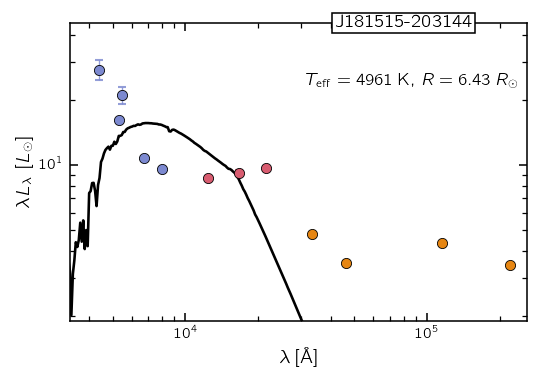

Inline SED 1/87


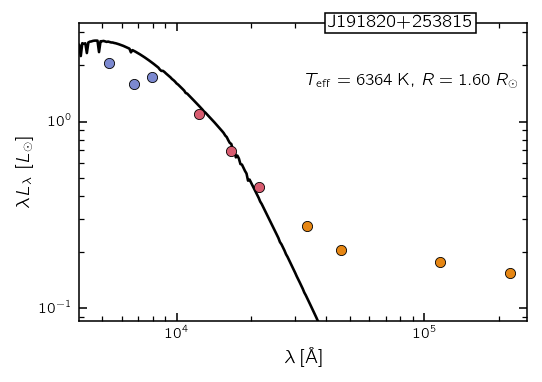

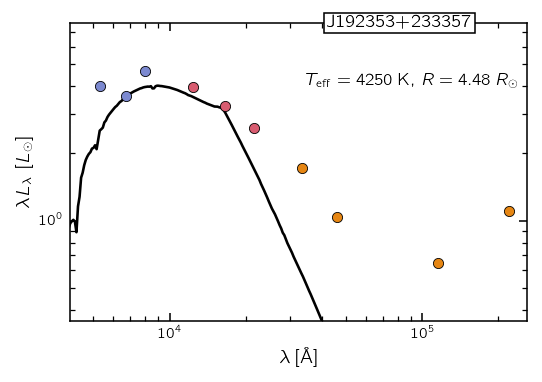

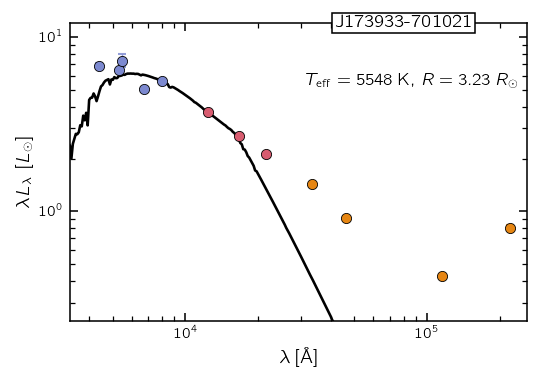

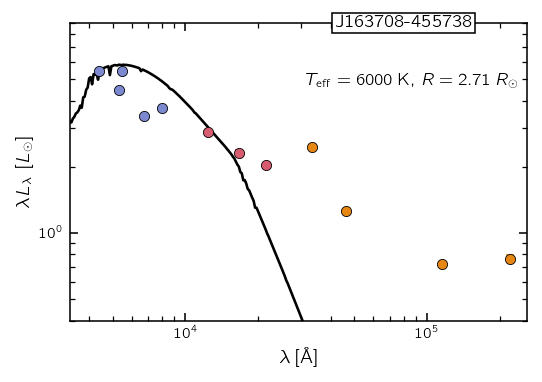

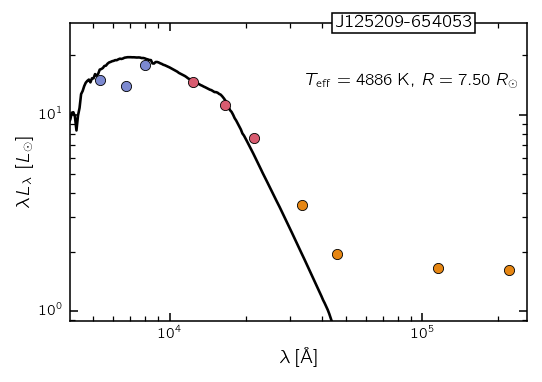

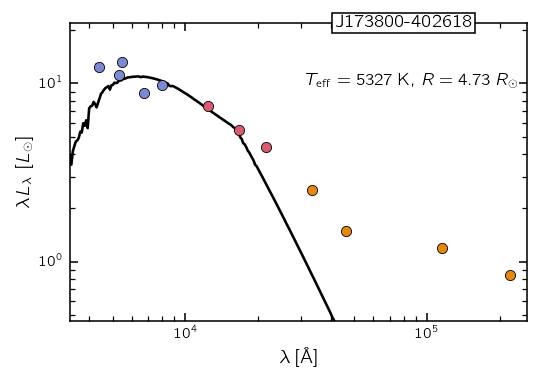

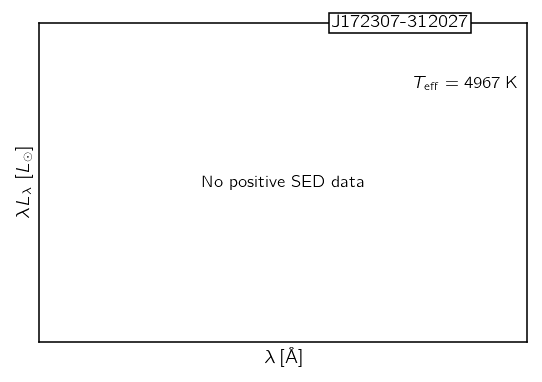

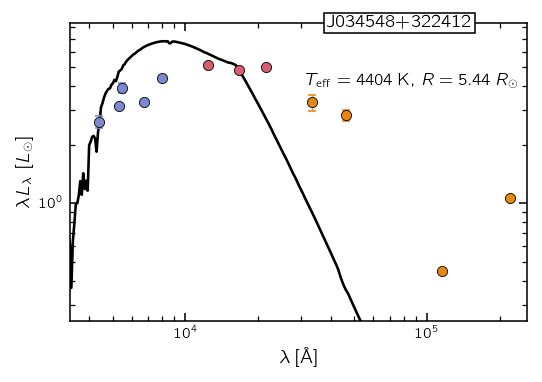

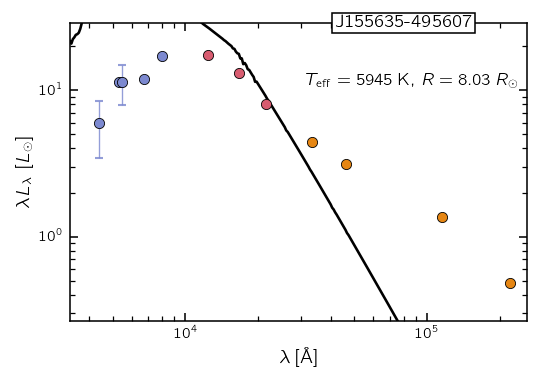

Inline SED 10/87


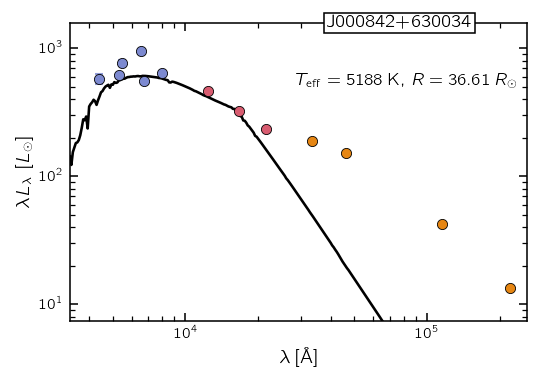

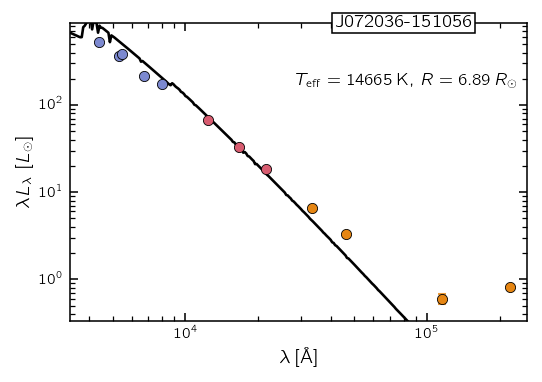

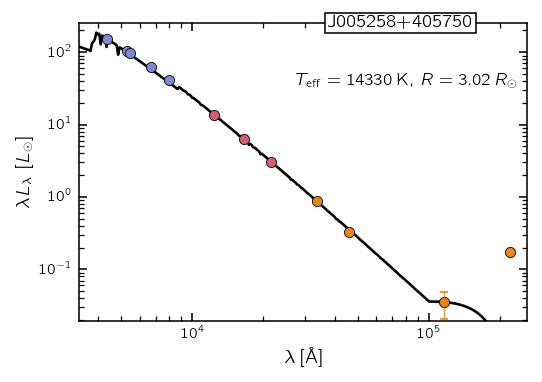

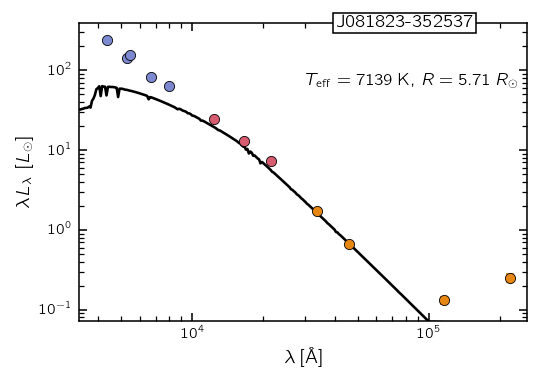

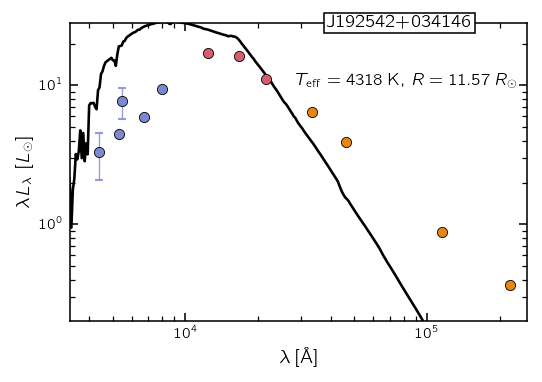

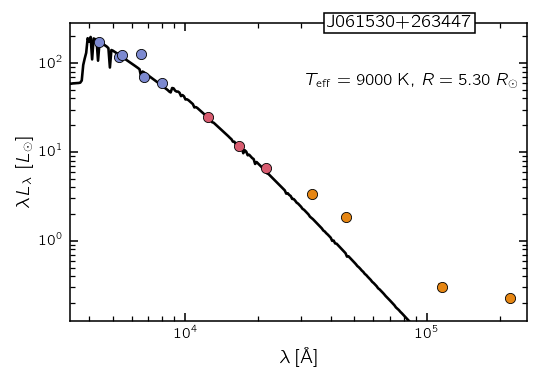

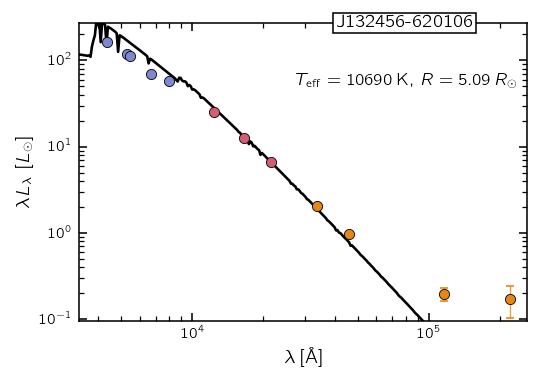

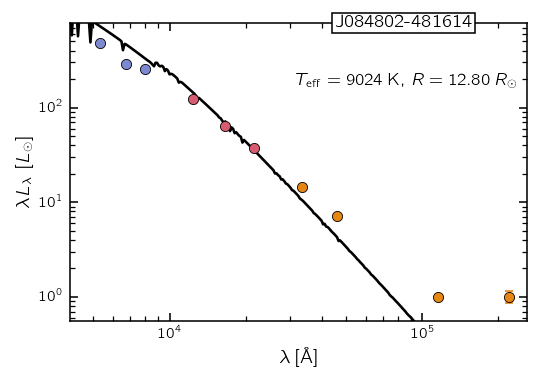

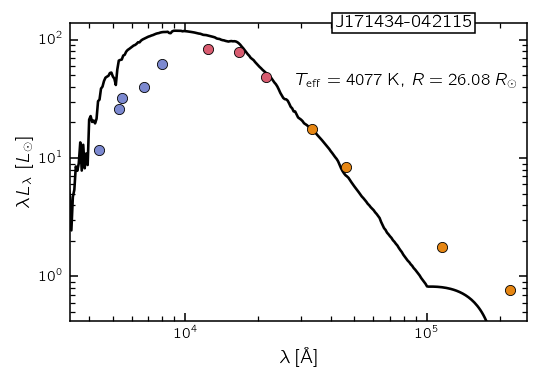

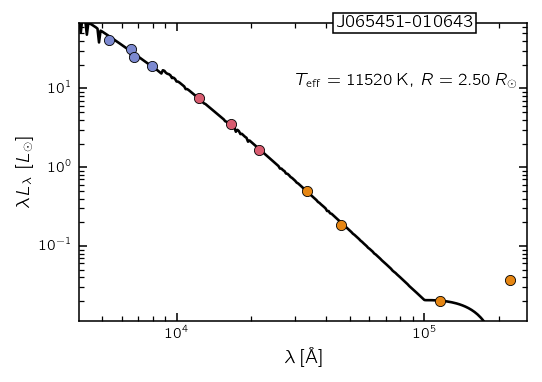

Inline SED 20/87


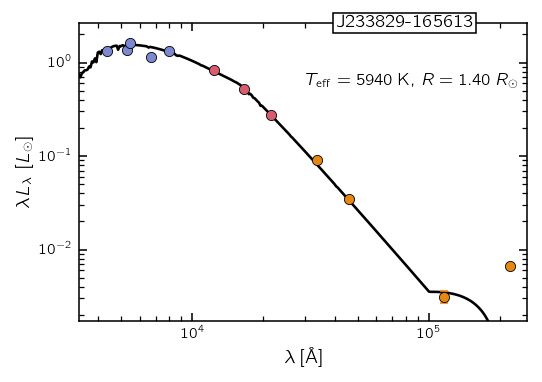

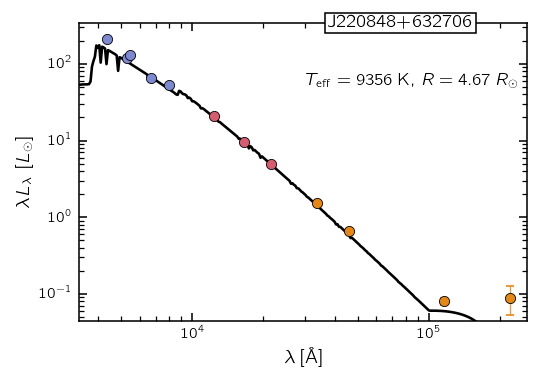

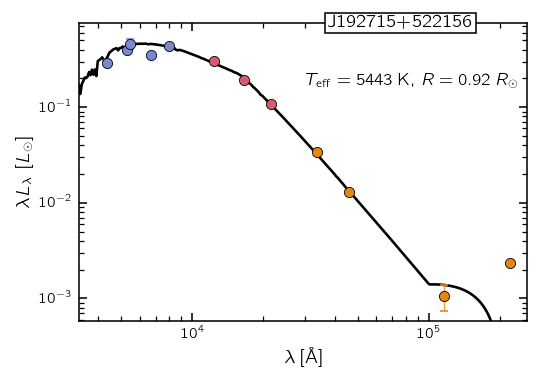

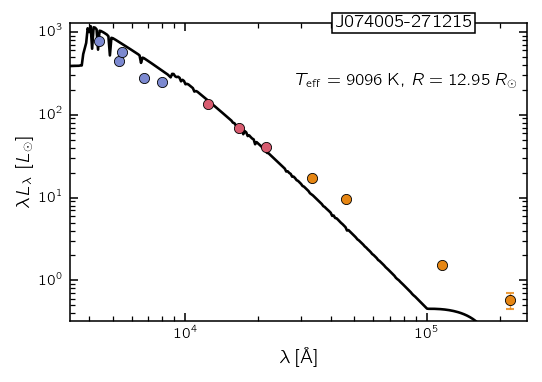

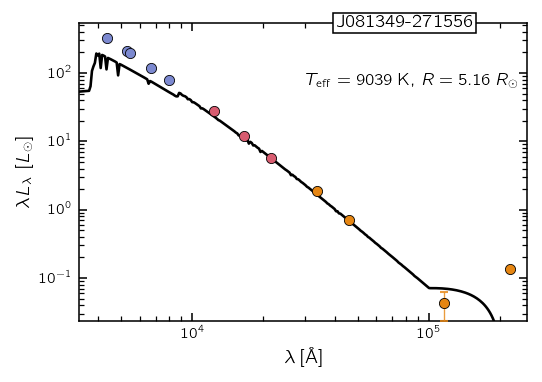

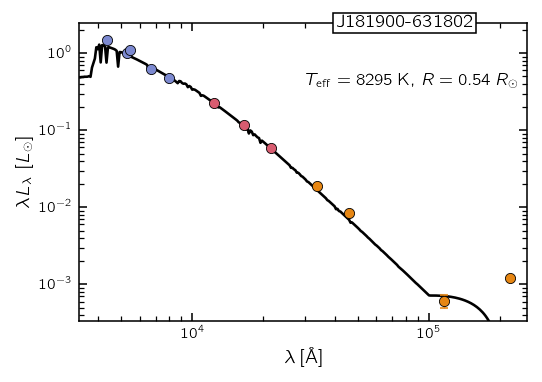

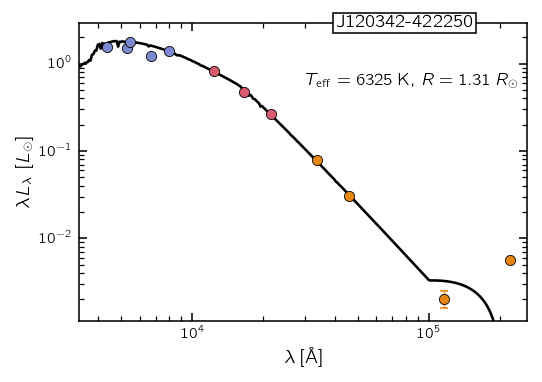

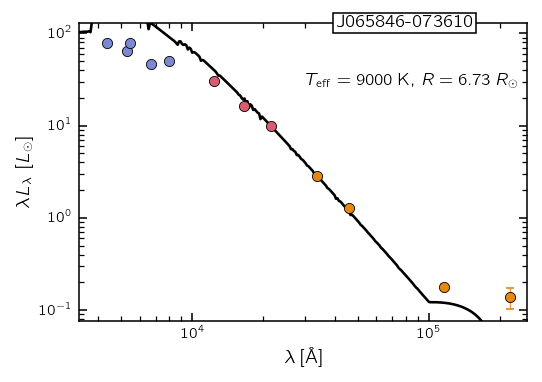

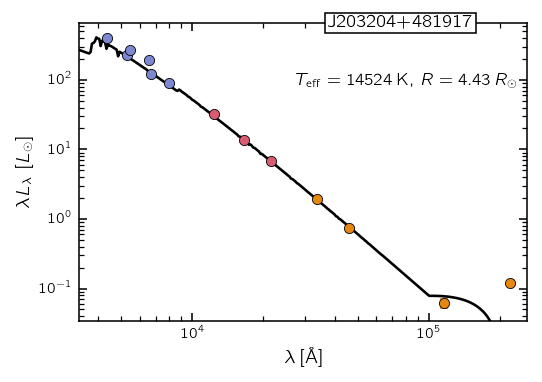

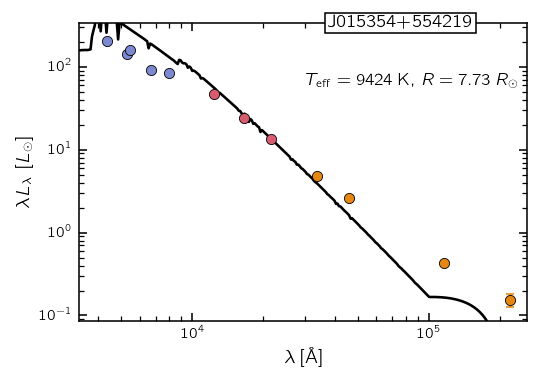

Inline SED 30/87


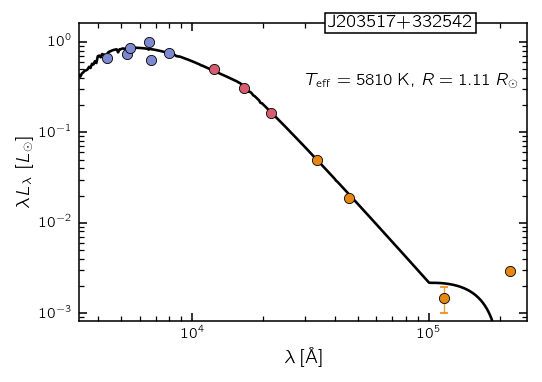

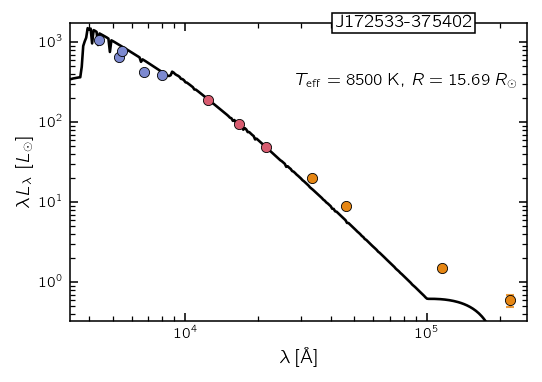

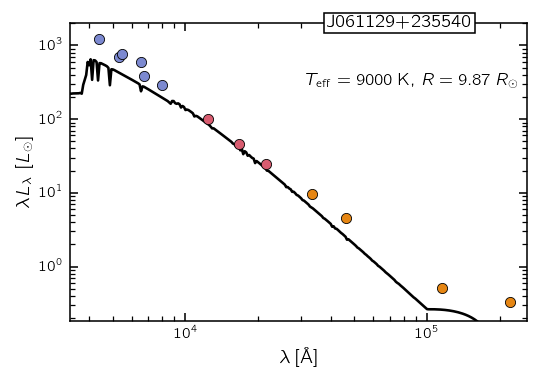

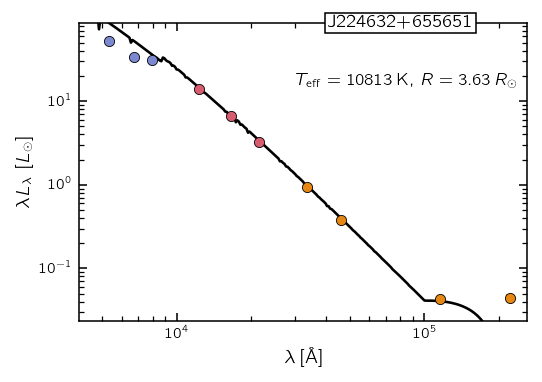

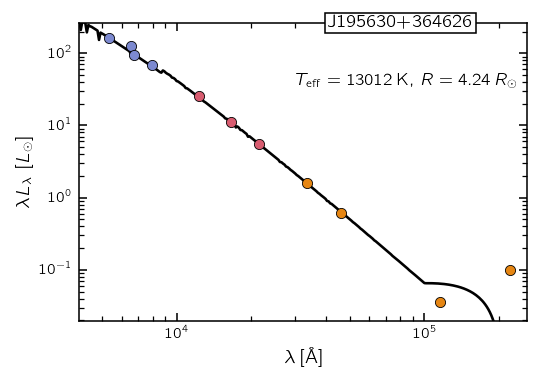

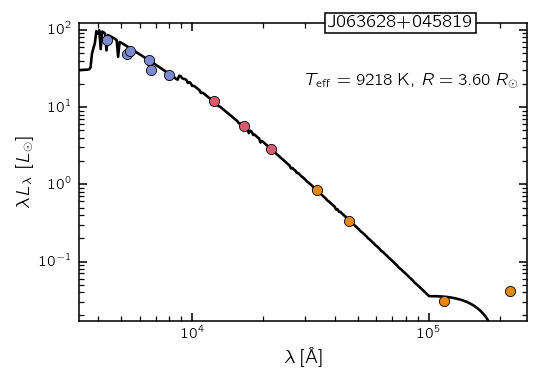

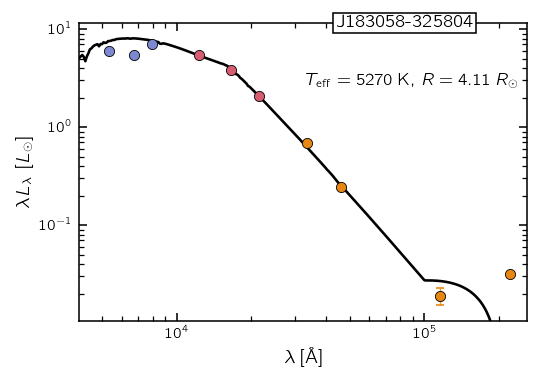

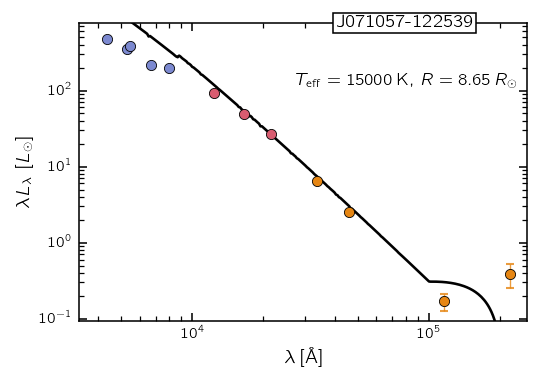

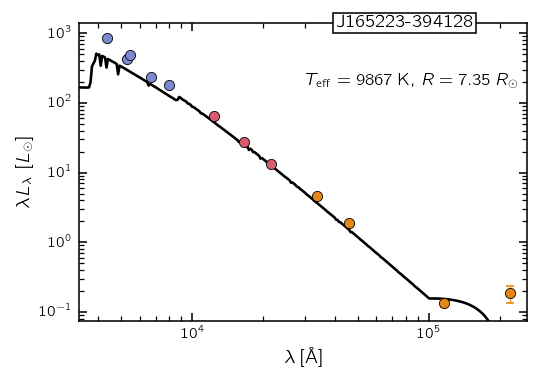

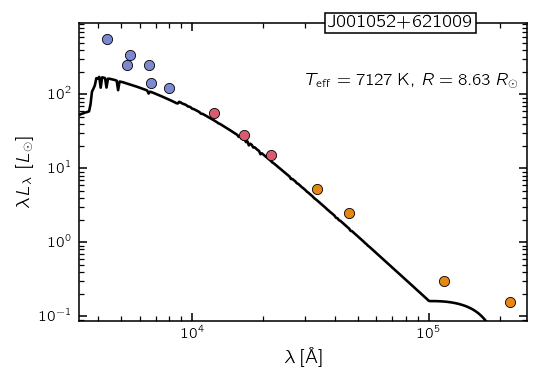

Inline SED 40/87


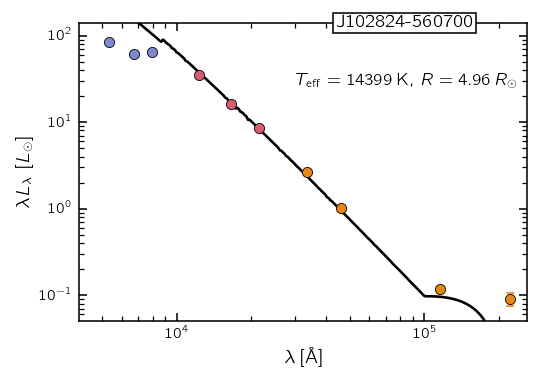

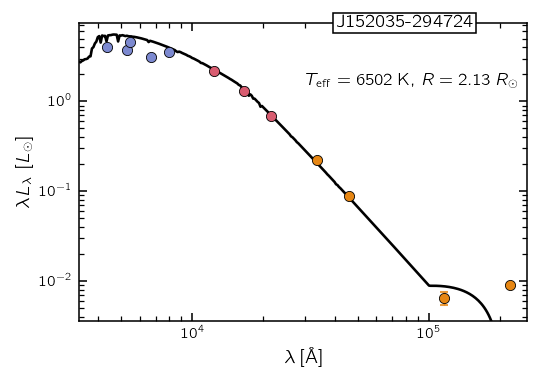

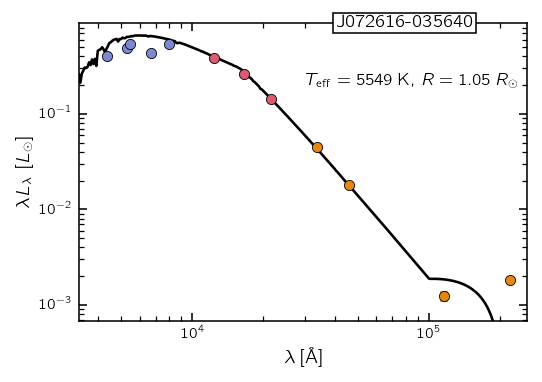

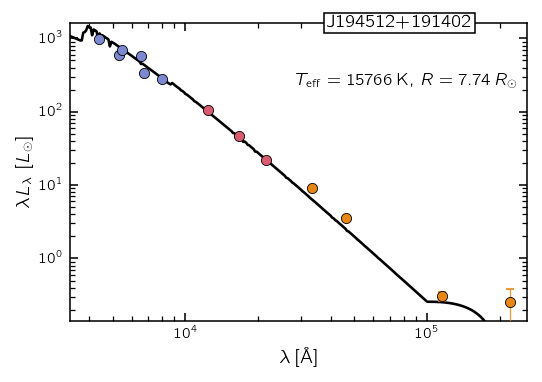

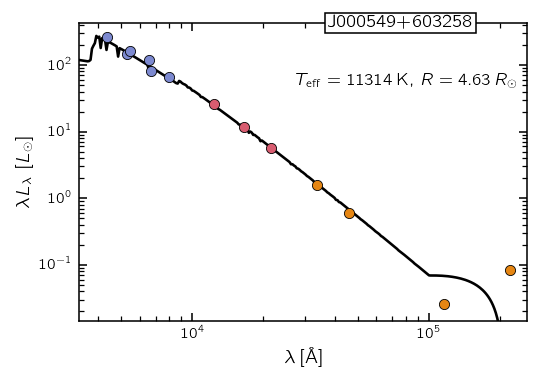

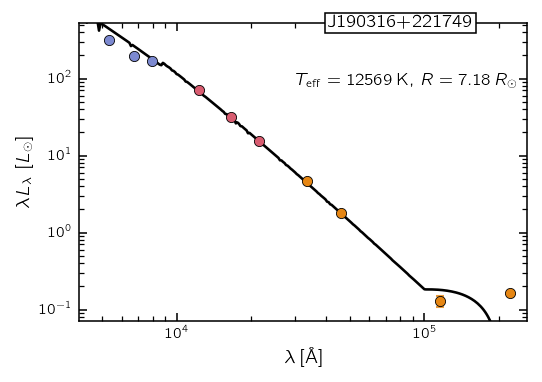

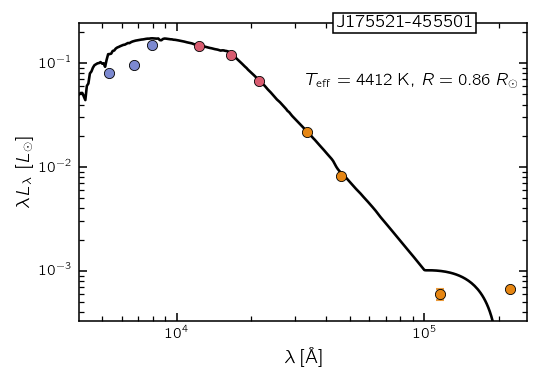

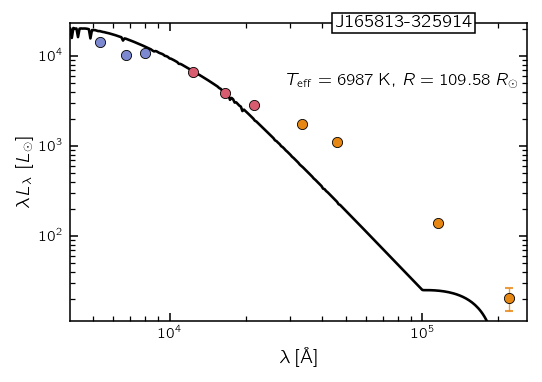

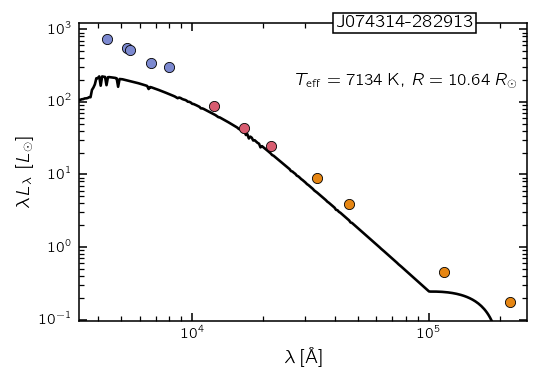

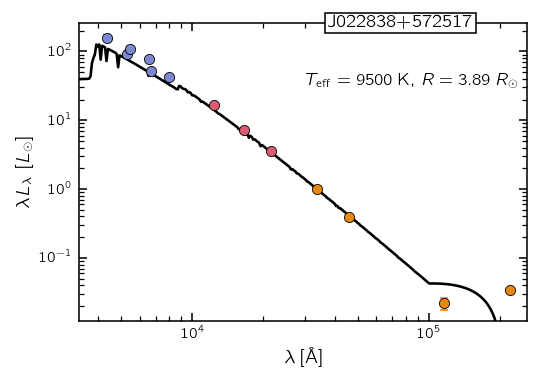

Inline SED 50/87


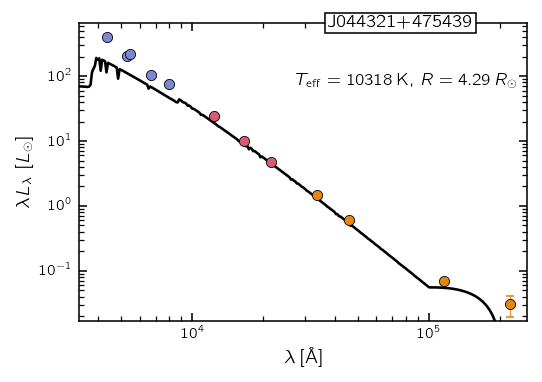

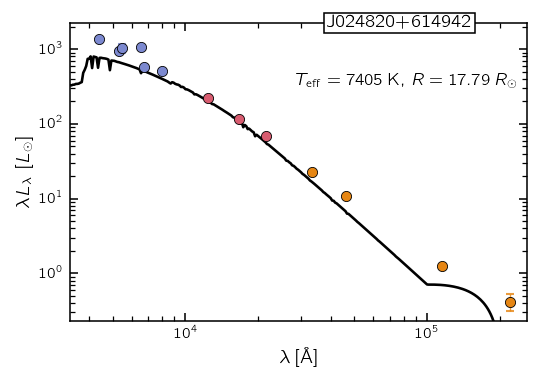

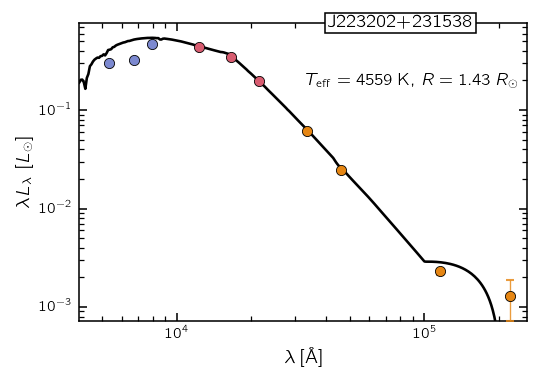

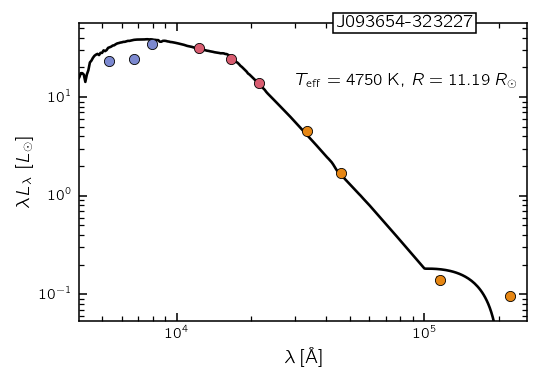

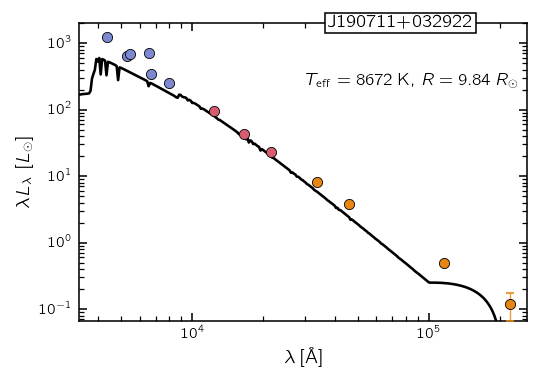

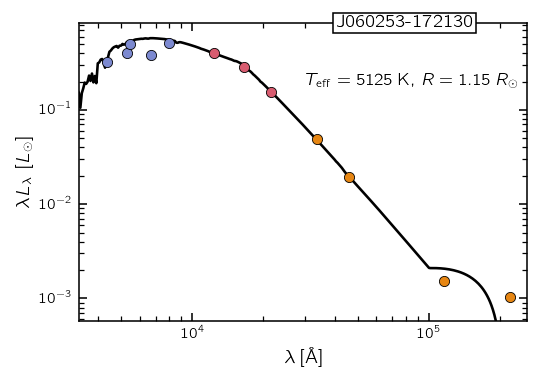

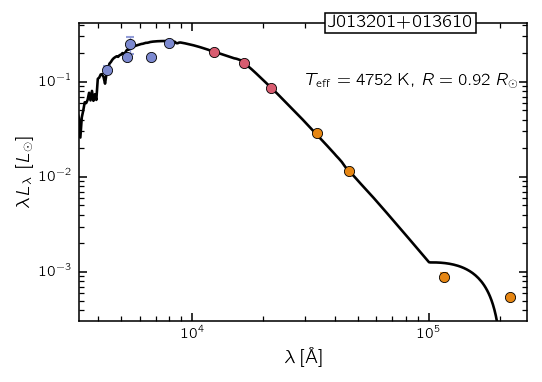

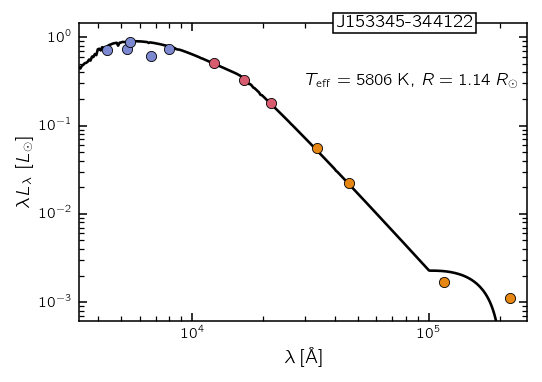

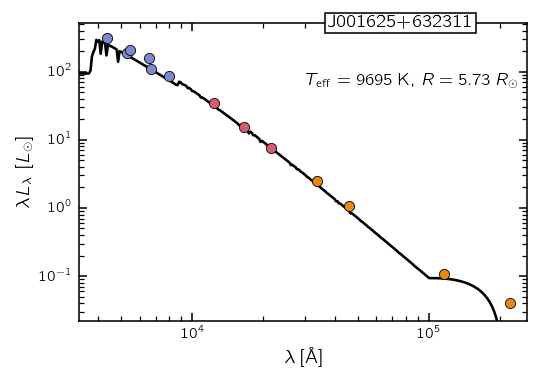

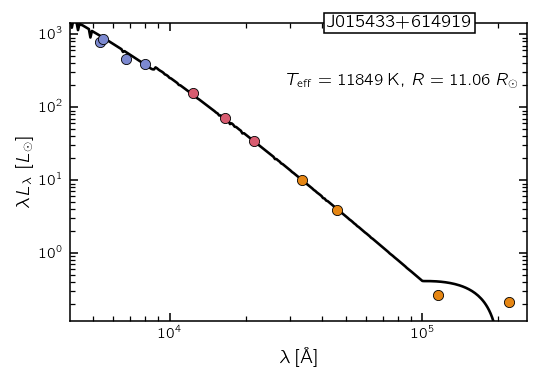

Inline SED 60/87


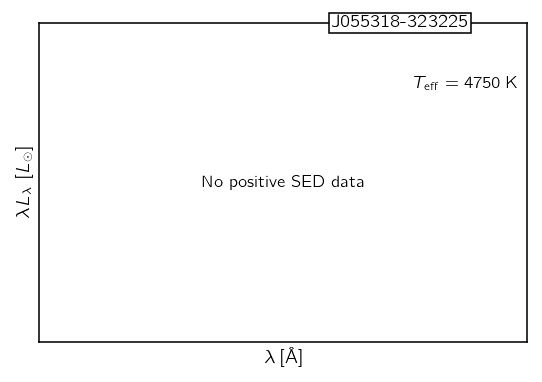

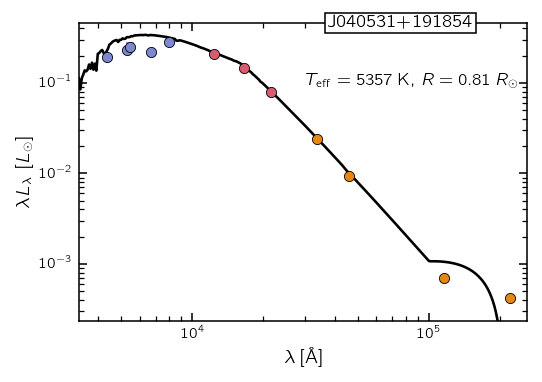

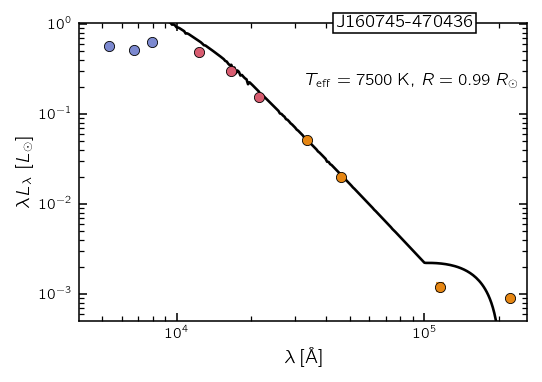

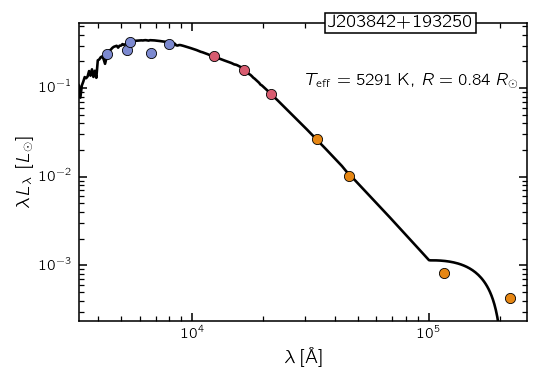

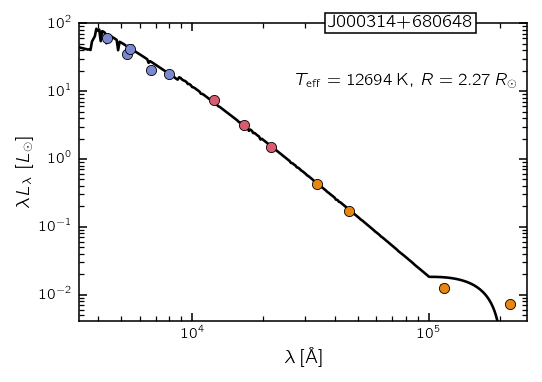

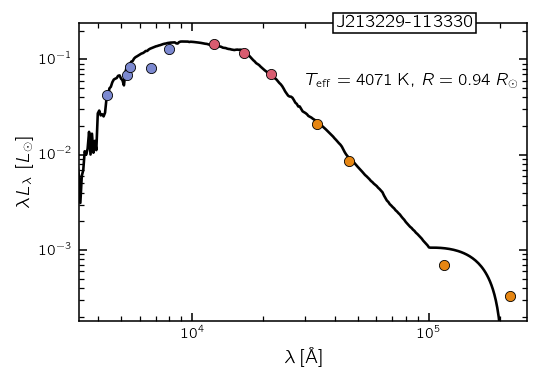

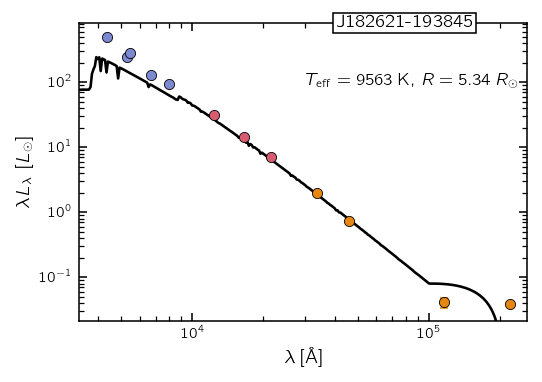

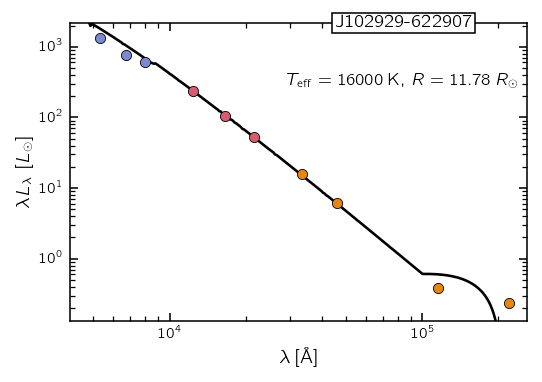

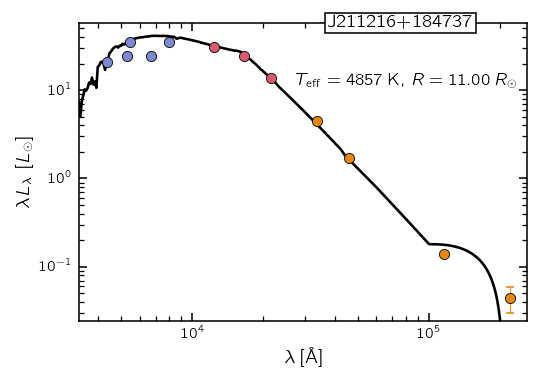

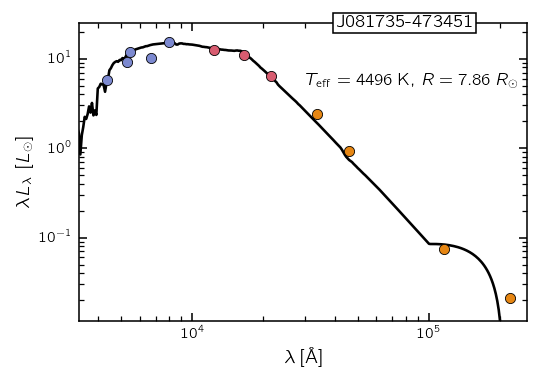

Inline SED 70/87


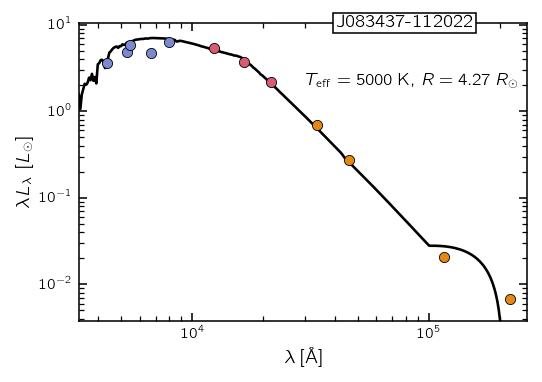

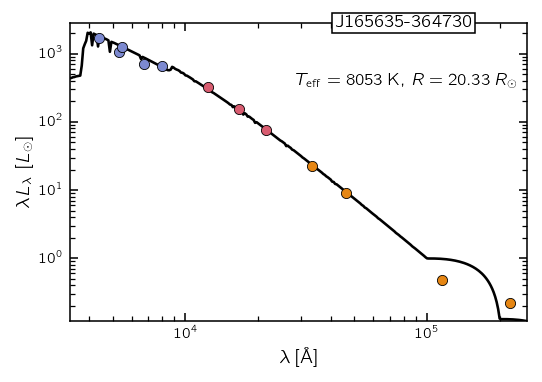

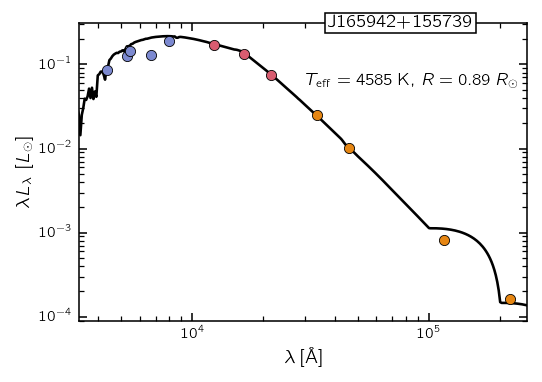

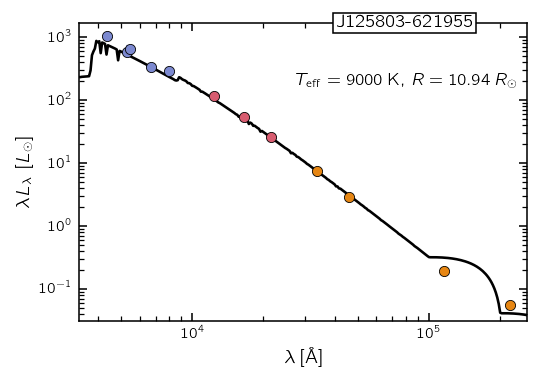

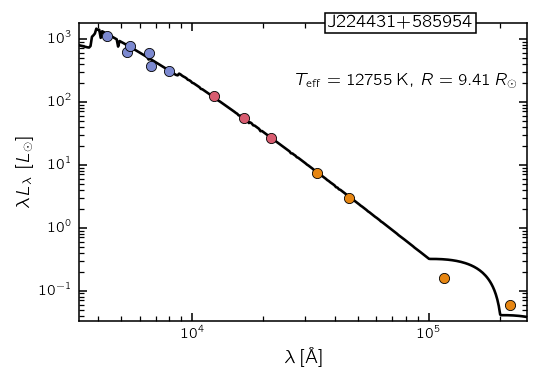

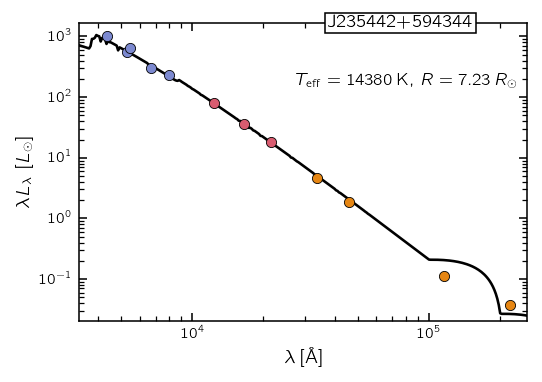

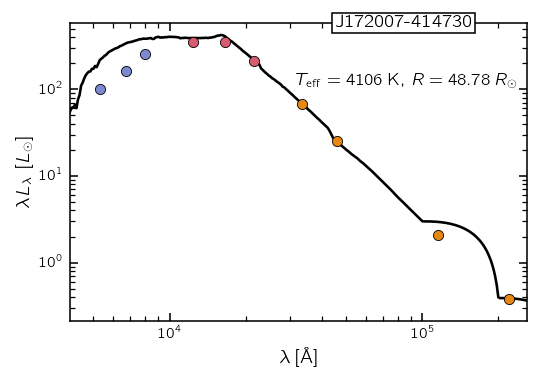

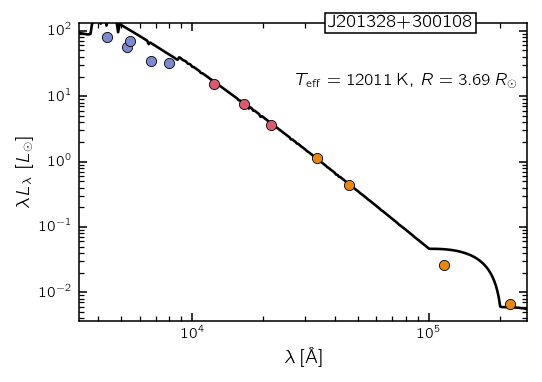

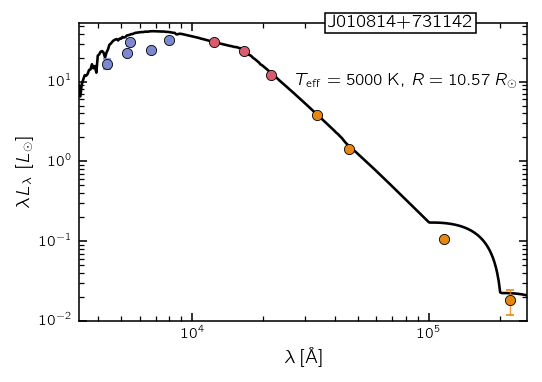

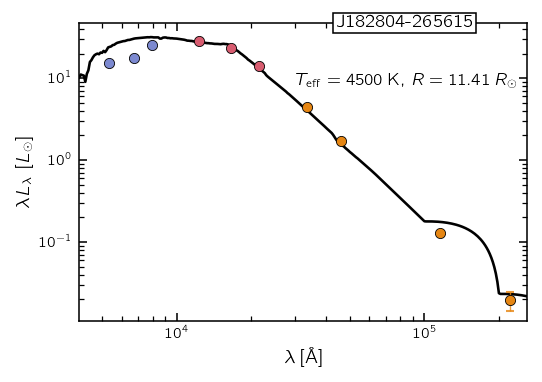

Inline SED 80/87


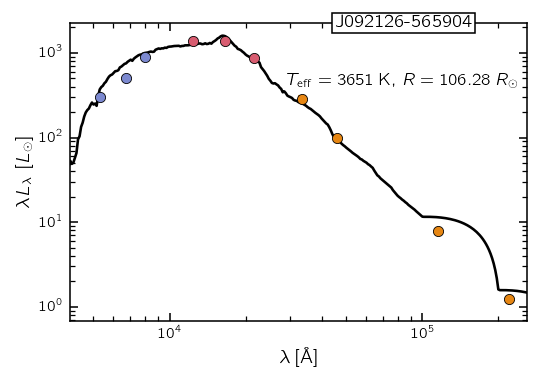

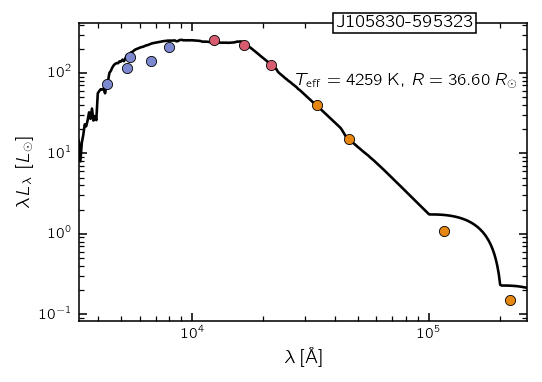

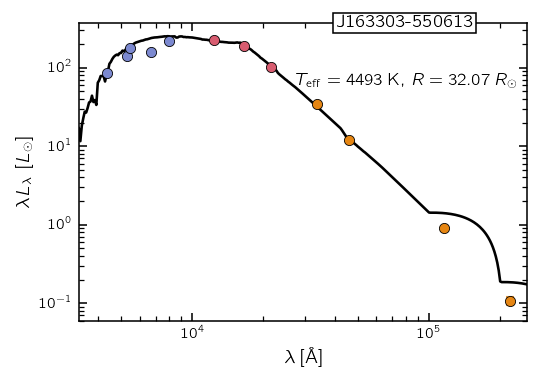

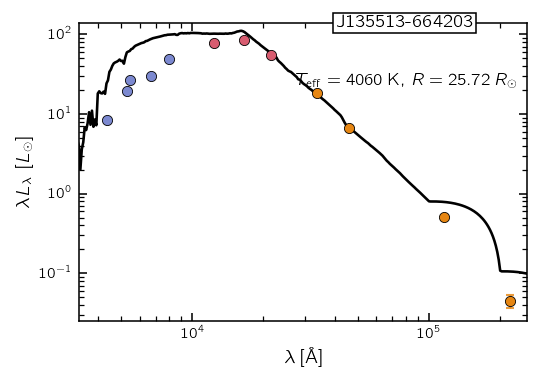

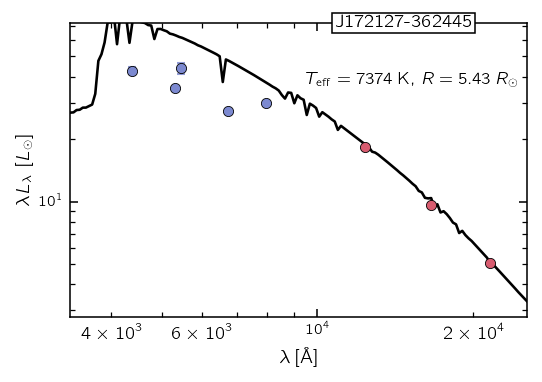

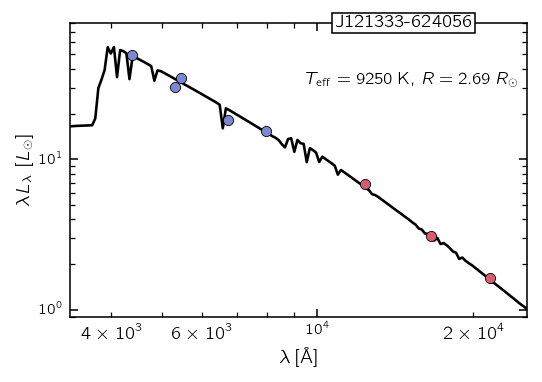

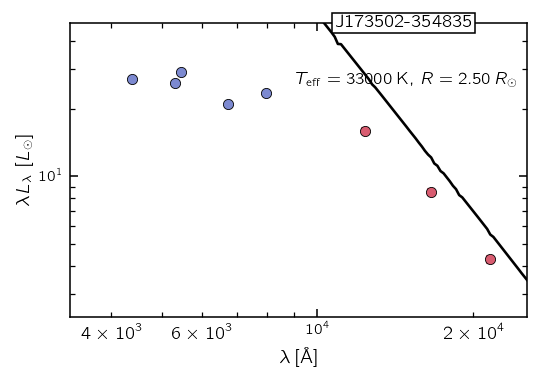

Inline SED 87/87


In [9]:
if DISPLAY_ALL:
    display_ids = candidate_summary['candidate_id'].astype(str).tolist()
    if DISPLAY_LIMIT is not None:
        display_ids = display_ids[:int(DISPLAY_LIMIT)]
    for index, candidate_id in enumerate(display_ids, start=1):
        display_candidate_sed(candidate_id)
        if index == 1 or index % 10 == 0 or index == len(display_ids):
            print(f'Inline SED {index}/{len(display_ids)}')
else:
    print('DISPLAY_ALL is False; no cohort SED figures were rendered inline.')

## Optional batch PDF export

Set `EXPORT_ALL = True` to produce one publication-style PDF per marked dipper under `results/marked_dipper_seds/pdf/`. If `pypdf` is available and `MERGE_PDF_ATLAS=True`, the same cell also creates a single multipage atlas. The review DB remains read-only.

In [10]:
def safe_filename(value: str) -> str:
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(value)).strip('_') or 'unknown'


def candidate_sed_pdf_bytes(candidate_id: str) -> bytes:
    fig = candidate_sed_column_figure(str(candidate_id))
    buf = BytesIO()
    fig.savefig(buf, format='pdf', dpi=300, bbox_inches='tight', pad_inches=0.06, metadata={'Creator': 'MALCA'})
    plt.close(fig)
    return buf.getvalue()


def export_candidate_pdfs(
    export_ids: list[str],
    *,
    merge_atlas: bool = True,
) -> pd.DataFrame:
    PDF_DIR.mkdir(parents=True, exist_ok=True)
    records = []
    pdf_blobs: list[tuple[str, bytes]] = []
    for index, candidate_id in enumerate(map(str, export_ids), start=1):
        try:
            fit_rows = fits_by_id.get(candidate_id, pd.DataFrame())
            fit_warning = str(fit_rows.iloc[0].get('warning') or '').strip() if not fit_rows.empty else ''
            warnings_list = [fit_warning] if fit_warning else []
            pdf_bytes = candidate_sed_pdf_bytes(candidate_id)
            pdf_path = PDF_DIR / f'malca_sed_{safe_filename(candidate_id)}_corrected.pdf'
            pdf_path.write_bytes(pdf_bytes)
            pdf_blobs.append((candidate_id, pdf_bytes))
            records.append({'candidate_id': candidate_id, 'status': 'ok', 'pdf_path': str(pdf_path), 'warnings': ' '.join(warnings_list)})
        except Exception as exc:
            records.append({'candidate_id': candidate_id, 'status': 'error', 'pdf_path': '', 'warnings': str(exc)})
        if index == 1 or index % 10 == 0 or index == len(export_ids):
            print(f'PDF export {index}/{len(export_ids)}')

    manifest = pd.DataFrame(records)
    manifest.to_csv(OUTPUT_DIR / 'marked_dipper_sed_pdf_manifest.csv', index=False)

    if merge_atlas and pdf_blobs:
        try:
            from pypdf import PdfReader, PdfWriter
            writer = PdfWriter()
            for _candidate_id, blob in pdf_blobs:
                for page in PdfReader(BytesIO(blob)).pages:
                    writer.add_page(page)
            atlas_path = OUTPUT_DIR / 'marked_dipper_sed_atlas.pdf'
            with atlas_path.open('wb') as handle:
                writer.write(handle)
            print(f'Wrote atlas: {atlas_path}')
        except ModuleNotFoundError:
            ghostscript = shutil.which('gs')
            if ghostscript is None:
                print('Atlas merge skipped: install pypdf or Ghostscript (gs).')
            else:
                atlas_path = OUTPUT_DIR / 'marked_dipper_sed_atlas.pdf'
                pdf_paths = [record['pdf_path'] for record in records if record['status'] == 'ok']
                subprocess.run([
                    ghostscript, '-dBATCH', '-dNOPAUSE', '-q', '-sDEVICE=pdfwrite',
                    f'-sOutputFile={atlas_path}', *pdf_paths,
                ], check=True)
                print(f'Wrote atlas with Ghostscript fallback: {atlas_path}')
        except Exception as exc:
            print(f'Atlas merge skipped: {exc}')
    return manifest


if EXPORT_ALL:
    export_ids = candidate_summary['candidate_id'].astype(str).tolist()
    if EXPORT_LIMIT is not None:
        export_ids = export_ids[:int(EXPORT_LIMIT)]
    export_manifest = export_candidate_pdfs(export_ids, merge_atlas=MERGE_PDF_ATLAS)
    display(export_manifest)
else:
    print('EXPORT_ALL is False; no per-candidate PDFs or atlas were generated.')

PDF export 1/87


PDF export 10/87


PDF export 20/87


PDF export 30/87


PDF export 40/87


...

PDF export 70/87


PDF export 80/87


PDF export 87/87


Wrote atlas with Ghostscript fallback: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/marked_dipper_seds/marked_dipper_sed_atlas.pdf


,candidate_id,status,pdf_path,warnings
0,stv_369367489518,ok,/Users/calder/code/malca/output/runs/dat3-full...,
1,stv_146029419304,ok,/Users/calder/code/malca/output/runs/dat3-full...,
2,stv_240518636016,ok,/Users/calder/code/malca/output/runs/dat3-full...,
3,stv_532576054353,ok,/Users/calder/code/malca/output/runs/dat3-full...,
4,stv_446677119900,ok,/Users/calder/code/malca/output/runs/dat3-full...,
5,stv_652835964994,ok,/Users/calder/code/malca/output/runs/dat3-full...,
6,stv_481036586933,ok,/Users/calder/code/malca/output/runs/dat3-full...,
7,stv_515396131751,ok,/Users/calder/code/malca/output/runs/dat3-full...,
8,stv_94489786439,ok,/Users/calder/code/malca/output/runs/dat3-full...,
9,stv_523987067704,ok,/Users/calder/code/malca/output/runs/dat3-full...,


## Interpretation guardrails

- The Kurucz temperature and scale are broadband-fit estimates, not posterior stellar parameters.
- The fit evaluates photometry at effective wavelengths rather than integrating model spectra through full filter response curves.
- The current extinction correction uses stored per-band coefficients.
- WISE photometry is non-simultaneous with the optical/NIR catalogs, which matters for variable dippers.
- Missing or underestimated W3/W4 uncertainties, upper limits, and source confusion can make model ratios look more significant than they are.
- Treat `sed_alpha`, W3/W4 ratios, and photometric-only significance as prioritization diagnostics; confirm interesting objects with image-level vetting, multi-epoch WISE behavior, and a stronger atmosphere/extinction treatment.